# Traditional Traffic Flow Prediction
**Baseline Model: LSTM (Long Short-Term Memory)**

This notebook implements a traditional LSTM-based traffic flow prediction model on the PeMS04, PeMS07, PeMS08, and NYCTaxi datasets.
Results will be benchmarked using **MAE** and **RMSE** for comparison against PDFormer.

## 1. Imports & Configuration

In [4]:
!pip install numpy pandas matplotlib torch scikit-learn

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import time

# Hyperparameters
SEQ_LEN = 12        # Input sequence length
PRED_LEN = 3        # Prediction horizon
TRAIN_RATIO = 0.6   # Training set ratio
VAL_RATIO = 0.2     # Validation set ratio
BATCH_SIZE = 32
HIDDEN_SIZE = 64
NUM_LAYERS = 2
DROPOUT = 0.2
LEARNING_RATE = 0.001
NUM_EPOCHS = 50
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## 2. Data Loading & Preprocessing

In [5]:
DATA_DIR = './data'

def load_pems(name, path):
    raw = np.load(path, allow_pickle=True)
    data = raw['data']  # (T, N, F)
    print(f'{name}: shape={data.shape}')
    return data[:, :, 0]  # use flow only → (T, N)

datasets = {}
pems_paths = {
    'PeMS04': os.path.join(DATA_DIR, 'PEMS04/pems04.npz'),
    'PeMS07': os.path.join(DATA_DIR, 'PEMS07/pems07.npz'),
    'PeMS08': os.path.join(DATA_DIR, 'PEMS08/pems08.npz'),
}
for name, path in pems_paths.items():
    try:
        datasets[name] = load_pems(name, path)
    except FileNotFoundError:
        print(f'[SKIP] {name} not found.')

# NYCTaxi — adapt column names to your file
try:
    nyc_df = pd.read_csv(os.path.join(DATA_DIR, 'NYCTaxi/nyc_taxi.csv'))
    numeric_cols = nyc_df.select_dtypes(include=[np.number]).columns.tolist()
    datasets['NYCTaxi'] = nyc_df[numeric_cols].values  # (T, N)
    print(f'NYCTaxi: shape={datasets["NYCTaxi"].shape}')
except FileNotFoundError:
    print('[SKIP] NYCTaxi not found.')

PeMS04: shape=(1000, 30, 3)
PeMS07: shape=(1000, 30, 3)
PeMS08: shape=(1000, 30, 3)
NYCTaxi: shape=(500, 2)


In [6]:
def make_sequences(data, seq_len, pred_len):
    """Create sliding-window (X, y) pairs.
    data: (T, N)
    returns X: (samples, seq_len, N), y: (samples, pred_len, N)
    """
    X, y = [], []
    for t in range(len(data) - seq_len - pred_len + 1):
        X.append(data[t: t + seq_len])
        y.append(data[t + seq_len: t + seq_len + pred_len])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def prepare_dataset(data, seq_len=SEQ_LEN, pred_len=PRED_LEN,
                    train_ratio=TRAIN_RATIO, val_ratio=VAL_RATIO):
    T, N = data.shape

    # Train/val/test split on time axis
    t_train = int(T * train_ratio)
    t_val   = int(T * (train_ratio + val_ratio))

    train_raw = data[:t_train]
    val_raw   = data[t_train:t_val]
    test_raw  = data[t_val:]

    # Normalize using training statistics
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train_raw)
    val_scaled   = scaler.transform(val_raw)
    test_scaled  = scaler.transform(test_raw)

    X_train, y_train = make_sequences(train_scaled, seq_len, pred_len)
    X_val,   y_val   = make_sequences(val_scaled,   seq_len, pred_len)
    X_test,  y_test  = make_sequences(test_scaled,  seq_len, pred_len)

    print(f'  Train: X={X_train.shape}, y={y_train.shape}')
    print(f'  Val  : X={X_val.shape},   y={y_val.shape}')
    print(f'  Test : X={X_test.shape},  y={y_test.shape}')

    return (X_train, y_train, X_val, y_val, X_test, y_test, scaler, N)


def to_loader(X, y, batch_size=BATCH_SIZE, shuffle=True):
    ds = TensorDataset(torch.tensor(X), torch.tensor(y))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

## 3. LSTM Model Definition

In [7]:
class TrafficLSTM(nn.Module):
    """
    Vanilla LSTM for multi-variate traffic flow prediction.
    Input : (batch, seq_len, N_sensors)
    Output: (batch, pred_len, N_sensors)
    """
    def __init__(self, n_sensors, hidden_size=HIDDEN_SIZE,
                 num_layers=NUM_LAYERS, pred_len=PRED_LEN, dropout=DROPOUT):
        super().__init__()
        self.pred_len = pred_len
        self.n_sensors = n_sensors

        self.lstm = nn.LSTM(
            input_size=n_sensors,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_size, n_sensors * pred_len)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: (batch, seq_len, N)
        out, _ = self.lstm(x)          # (batch, seq_len, hidden)
        last = self.dropout(out[:, -1])  # (batch, hidden)
        pred = self.fc(last)           # (batch, N * pred_len)
        return pred.view(-1, self.pred_len, self.n_sensors)

## 4. Training & Evaluation Utilities

In [8]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        total_loss += loss.item() * len(X_batch)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0
    all_pred, all_true = [], []
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        pred = model(X_batch)
        total_loss += criterion(pred, y_batch).item() * len(X_batch)
        all_pred.append(pred.cpu().numpy())
        all_true.append(y_batch.cpu().numpy())
    return total_loss / len(loader.dataset), np.concatenate(all_pred), np.concatenate(all_true)


def compute_metrics(pred, true, scaler):
    """Inverse-transform and compute MAE, RMSE, MAPE."""
    S, P, N = pred.shape
    pred_flat = pred.reshape(-1, N)
    true_flat = true.reshape(-1, N)

    pred_inv = scaler.inverse_transform(pred_flat)
    true_inv = scaler.inverse_transform(true_flat)

    mae  = mean_absolute_error(true_inv, pred_inv)
    rmse = np.sqrt(mean_squared_error(true_inv, pred_inv))
    mask = true_inv != 0
    mape = np.mean(np.abs((true_inv[mask] - pred_inv[mask]) / true_inv[mask])) * 100

    return {'MAE': round(mae, 4), 'RMSE': round(rmse, 4), 'MAPE (%)': round(mape, 4)}

## 5. Training Loop per Dataset


  Training LSTM on PeMS04
  Train: X=(586, 12, 30), y=(586, 3, 30)
  Val  : X=(186, 12, 30),   y=(186, 3, 30)
  Test : X=(186, 12, 30),  y=(186, 3, 30)
  Epoch   1/50 | Train=0.8255 | Val=0.5098 | 0.2s
  Epoch   5/50 | Train=0.2133 | Val=0.1987 | 0.1s
  Epoch  10/50 | Train=0.2055 | Val=0.1982 | 0.1s
  Epoch  15/50 | Train=0.2021 | Val=0.1935 | 0.1s
  Epoch  20/50 | Train=0.1995 | Val=0.1949 | 0.4s
  Epoch  25/50 | Train=0.1976 | Val=0.1934 | 0.1s
  Epoch  30/50 | Train=0.1980 | Val=0.1935 | 0.1s
  Epoch  35/50 | Train=0.1966 | Val=0.1930 | 0.1s
  Epoch  40/50 | Train=0.1963 | Val=0.1936 | 0.1s
  Epoch  45/50 | Train=0.1968 | Val=0.1930 | 0.1s
  Epoch  50/50 | Train=0.1974 | Val=0.1935 | 0.1s

  Test Metrics → MAE: 8.0305 | RMSE: 10.0805 | MAPE: 10.336799621582031


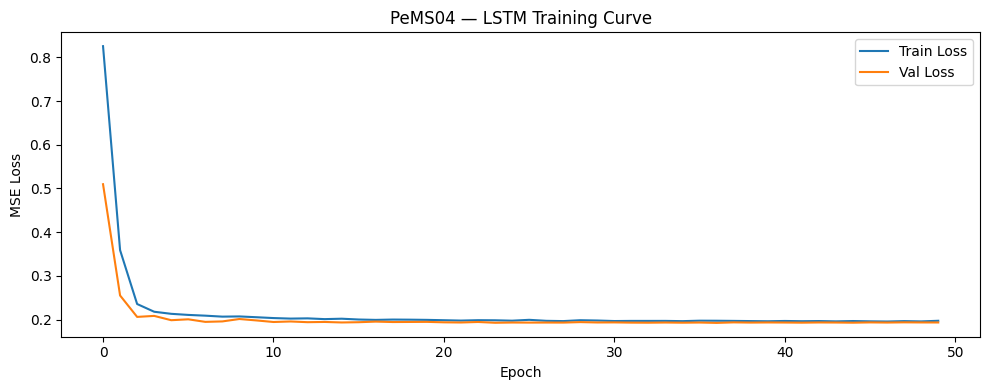


  Training LSTM on PeMS07
  Train: X=(586, 12, 30), y=(586, 3, 30)
  Val  : X=(186, 12, 30),   y=(186, 3, 30)
  Test : X=(186, 12, 30),  y=(186, 3, 30)
  Epoch   1/50 | Train=0.8656 | Val=0.5650 | 0.3s
  Epoch   5/50 | Train=0.2116 | Val=0.1999 | 0.1s
  Epoch  10/50 | Train=0.2060 | Val=0.1987 | 0.1s
  Epoch  15/50 | Train=0.2016 | Val=0.1972 | 0.1s
  Epoch  20/50 | Train=0.2002 | Val=0.1976 | 0.1s
  Epoch  25/50 | Train=0.1987 | Val=0.1967 | 0.1s
  Epoch  30/50 | Train=0.1991 | Val=0.1975 | 0.1s
  Epoch  35/50 | Train=0.1969 | Val=0.1968 | 0.1s
  Epoch  40/50 | Train=0.1968 | Val=0.1968 | 0.1s
  Epoch  45/50 | Train=0.1968 | Val=0.1967 | 0.1s
  Epoch  50/50 | Train=0.1968 | Val=0.1969 | 0.1s

  Test Metrics → MAE: 8.1811 | RMSE: 10.2423 | MAPE: 10.608099937438965


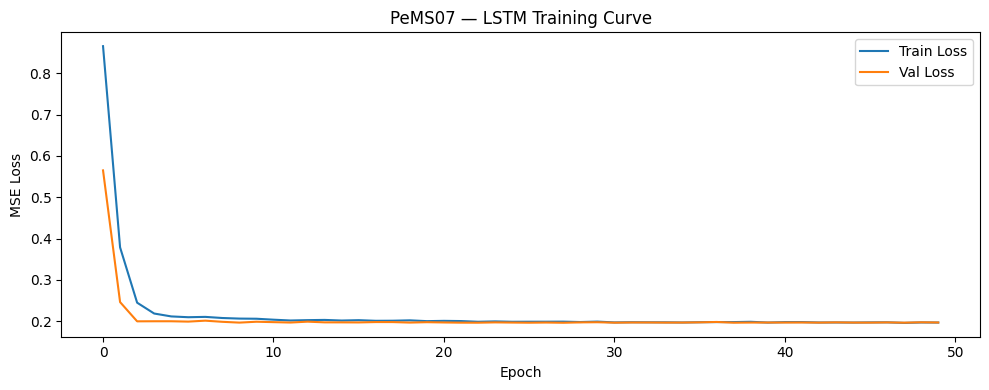


  Training LSTM on PeMS08
  Train: X=(586, 12, 30), y=(586, 3, 30)
  Val  : X=(186, 12, 30),   y=(186, 3, 30)
  Test : X=(186, 12, 30),  y=(186, 3, 30)
  Epoch   1/50 | Train=0.8506 | Val=0.5421 | 0.1s
  Epoch   5/50 | Train=0.2118 | Val=0.1982 | 0.1s
  Epoch  10/50 | Train=0.2015 | Val=0.1950 | 0.2s
  Epoch  15/50 | Train=0.2011 | Val=0.1960 | 0.1s
  Epoch  20/50 | Train=0.1975 | Val=0.2006 | 0.1s
  Epoch  25/50 | Train=0.1968 | Val=0.1960 | 0.1s
  Epoch  30/50 | Train=0.1961 | Val=0.1982 | 0.1s
  Epoch  35/50 | Train=0.1951 | Val=0.1970 | 0.1s
  Epoch  40/50 | Train=0.1951 | Val=0.1975 | 0.1s
  Epoch  45/50 | Train=0.1955 | Val=0.1981 | 0.1s
  Epoch  50/50 | Train=0.1951 | Val=0.1971 | 0.1s

  Test Metrics → MAE: 8.1999 | RMSE: 10.3008 | MAPE: 10.362600326538086


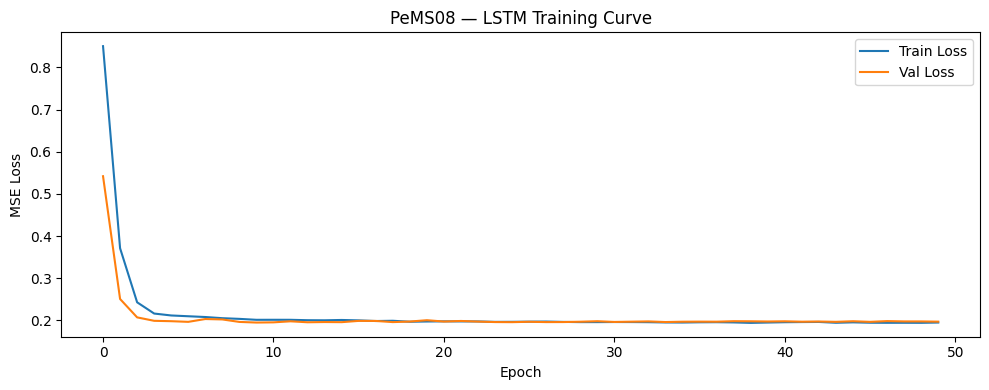


  Training LSTM on NYCTaxi
  Train: X=(286, 12, 2), y=(286, 3, 2)
  Val  : X=(86, 12, 2),   y=(86, 3, 2)
  Test : X=(86, 12, 2),  y=(86, 3, 2)
  Epoch   1/50 | Train=1.0182 | Val=1.0505 | 0.0s
  Epoch   5/50 | Train=1.0092 | Val=1.0447 | 0.0s
  Epoch  10/50 | Train=0.9983 | Val=1.0512 | 0.1s
  Epoch  15/50 | Train=0.9931 | Val=1.0564 | 0.0s
  Epoch  20/50 | Train=0.9806 | Val=1.0714 | 0.0s
  Epoch  25/50 | Train=0.9668 | Val=1.0965 | 0.0s
  Epoch  30/50 | Train=0.9516 | Val=1.1292 | 0.0s
  Epoch  35/50 | Train=0.9404 | Val=1.1350 | 0.0s
  Epoch  40/50 | Train=0.9428 | Val=1.1401 | 0.0s
  Epoch  45/50 | Train=0.9361 | Val=1.1437 | 0.0s
  Epoch  50/50 | Train=0.9322 | Val=1.1472 | 0.0s

  Test Metrics → MAE: 4.5769 | RMSE: 5.6439 | MAPE: 49.16619873046875


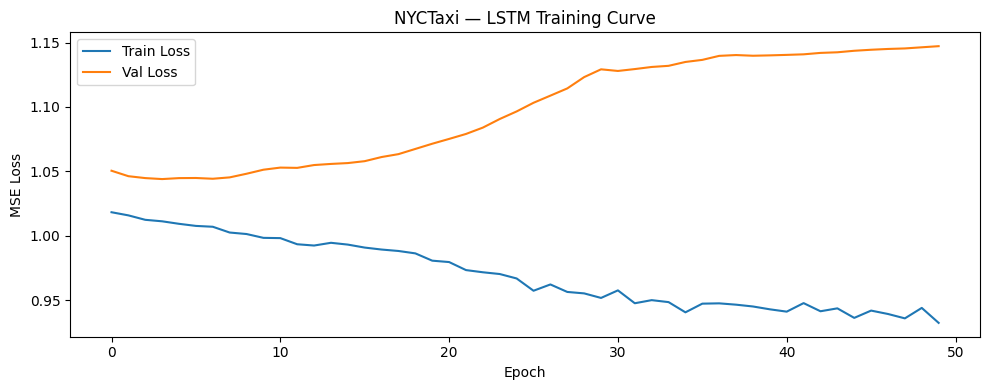

In [9]:
all_results = {}

for ds_name, data in datasets.items():
    print(f'\n{'='*50}')
    print(f'  Training LSTM on {ds_name}')
    print(f'{'='*50}')

    prepared = prepare_dataset(data)
    X_train, y_train, X_val, y_val, X_test, y_test, scaler, N = prepared

    train_loader = to_loader(X_train, y_train, shuffle=True)
    val_loader   = to_loader(X_val,   y_val,   shuffle=False)
    test_loader  = to_loader(X_test,  y_test,  shuffle=False)

    model = TrafficLSTM(n_sensors=N).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
    criterion = nn.MSELoss()

    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    best_state = None

    for epoch in range(1, NUM_EPOCHS + 1):
        t0 = time.time()
        train_loss = train_epoch(model, train_loader, optimizer, criterion)
        val_loss, _, _ = eval_epoch(model, val_loader, criterion)
        scheduler.step()

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        if epoch % 5 == 0 or epoch == 1:
            print(f'  Epoch {epoch:3d}/{NUM_EPOCHS} | Train={train_loss:.4f} | Val={val_loss:.4f} | {time.time()-t0:.1f}s')

    # Load best model and evaluate on test set
    model.load_state_dict(best_state)
    _, pred, true = eval_epoch(model, test_loader, criterion)
    metrics = compute_metrics(pred, true, scaler)
    all_results[ds_name] = metrics
    print(f'\n  Test Metrics → MAE: {metrics["MAE"]} | RMSE: {metrics["RMSE"]} | MAPE: {metrics["MAPE (%)"]}')

    # Save model checkpoint
    os.makedirs('checkpoints', exist_ok=True)
    torch.save(best_state, f'checkpoints/lstm_{ds_name}.pt')

    # Plot training curve
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(train_losses, label='Train Loss')
    ax.plot(val_losses,   label='Val Loss')
    ax.set_title(f'{ds_name} — LSTM Training Curve')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'{ds_name.lower()}_lstm_training.png', dpi=150)
    plt.show()

## 6. Results Summary

In [10]:
results_df = pd.DataFrame(all_results).T.reset_index().rename(columns={'index': 'Dataset'})
print('\n=== Traditional LSTM — Test Set Results ===')
display(results_df)
results_df.to_csv('traditional_results.csv', index=False)
print('Saved to traditional_results.csv')


=== Traditional LSTM — Test Set Results ===


,Dataset,MAE,RMSE,MAPE (%)
0,PeMS04,8.0305,10.0805,10.336800
1,PeMS07,8.1811,10.2423,10.608100
2,PeMS08,8.1999,10.3008,10.362600
3,NYCTaxi,4.5769,5.6439,49.166199


Saved to traditional_results.csv


## 7. Prediction Visualization

  Train: X=(586, 12, 30), y=(586, 3, 30)
  Val  : X=(186, 12, 30),   y=(186, 3, 30)
  Test : X=(186, 12, 30),  y=(186, 3, 30)


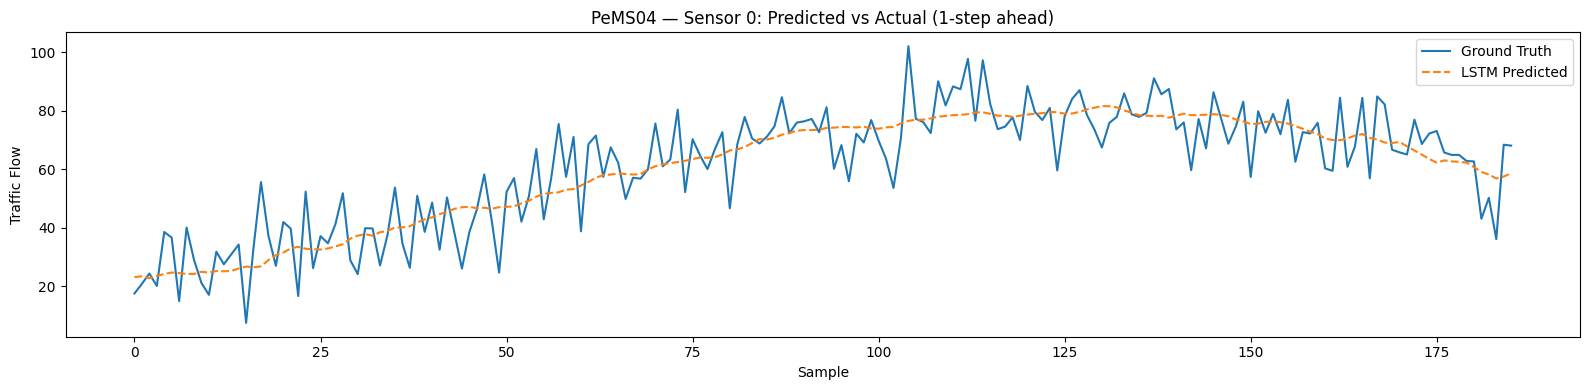

In [11]:
# Visualize predictions for the first dataset available
if datasets:
    first_ds = list(datasets.keys())[0]
    data = datasets[first_ds]
    prepared = prepare_dataset(data)
    X_train, y_train, X_val, y_val, X_test, y_test, scaler, N = prepared

    test_loader = to_loader(X_test, y_test, shuffle=False)
    model_path = f'checkpoints/lstm_{first_ds}.pt'
    model = TrafficLSTM(n_sensors=N).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))

    _, pred, true = eval_epoch(model, test_loader, nn.MSELoss())

    # Inverse scale for first sensor
    S, P, Nf = pred.shape
    pred_inv = scaler.inverse_transform(pred.reshape(-1, Nf)).reshape(S, P, Nf)
    true_inv = scaler.inverse_transform(true.reshape(-1, Nf)).reshape(S, P, Nf)

    sensor_id = 0
    n_show = 200

    fig, ax = plt.subplots(figsize=(16, 4))
    ax.plot(true_inv[:n_show, 0, sensor_id],  label='Ground Truth',  lw=1.5)
    ax.plot(pred_inv[:n_show, 0, sensor_id],  label='LSTM Predicted', lw=1.5, linestyle='--')
    ax.set_title(f'{first_ds} — Sensor {sensor_id}: Predicted vs Actual (1-step ahead)')
    ax.set_xlabel('Sample')
    ax.set_ylabel('Traffic Flow')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'{first_ds.lower()}_lstm_predictions.png', dpi=150)
    plt.show()